# 04 · Labeling — defining the future we're trying to predict

> ⏱️ **~25 min** &nbsp;·&nbsp; 🧭 **SOP:** Phase 4 · Label factory &nbsp;·&nbsp; 🧩 **Feeds:** ALL editions — labels are the 'answer key' that discovery (08) and backtests (09) score against
>
> 🎯 **Goal:** Attach a forward-looking target to every bar: simple forward returns, and the path-aware triple-barrier outcome.
>
> 🔑 **The one thing to remember:** **Features look back, labels look forward.** Labels are the *only* thing allowed to use the future — and the last H bars have no answer yet (NaN).

## Notebook 04 in one breath

> **Where we are.** Notebook 03 gave every bar a description of *now* (features `X`). To do supervised
> learning or even to *measure* whether a signal works, we need the *answer*: what happened **next**
> (label `y`). This is the Python mirror of `pipeline/labels.py`.

> 📘 **Concept — supervised learning, in one line.** Learn a mapping `features(t) → label(t)` from many
> examples, where the label summarizes the future. Get the label wrong and *nothing* downstream can be
> right — labeling is as important as feature engineering, and far more often botched.

**What you'll learn:**
1. The simplest label: **forward return**, and the lookahead *asymmetry* that makes it legal.
2. Why plain forward returns are a poor *trading* target (they ignore the **path**).
3. The **triple-barrier method** — a path-aware label that mimics a real TP/SL trade.
4. **Class balance**, and why a 50/50 label is itself an important (honest) finding.

In [1]:
# --- Standard setup (run me first) -------------------------------------------------
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import duckdb                 # streams Parquet/CSV without loading it all into RAM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    """Walk up until we see the repo's pipeline/ + data/ — works from any sub-dir."""
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pipeline").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError("repo root (with pipeline/ and data/) not found above " + str(start))

ROOT = _find_root(Path.cwd())
DATA = ROOT / "data"
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `from pipeline import ...` works (the real Layer-1 code)
con  = duckdb.connect()       # one in-memory DuckDB connection we reuse all notebook

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

print("repo root :", ROOT)
print("data dir  :", DATA)

repo root : /Users/tokyotechies/Workspace/KEM/dquants
data dir  : /Users/tokyotechies/Workspace/KEM/dquants/data


In [2]:
from pipeline import labels as lab, indicators as ind
bars = pd.read_parquet(DATA / "processed" / "bars_btcusd_M3_2026.parquet").sort_values("ts").reset_index(drop=True)
c = bars["close"]
print(f"loaded {len(bars):,} M3 bars")

loaded 76,800 M3 bars


## Step 1 · The simplest label — forward return

The most basic target: *how much did price move over the next `k` bars?*
`fwd_ret_k(t) = close(t + k) / close(t) − 1`. In pandas that's `close.shift(-k)` — a **negative** shift
pulls the future backward into row `t` **on purpose**. This is the one place leakage is the goal.

In [3]:
for k in (5, 10, 20, 60):
    bars[f"fwd_ret_{k}"] = c.shift(-k) / c - 1.0
bars[["ts", "close", "fwd_ret_5", "fwd_ret_10", "fwd_ret_60"]].head(3)

,ts,close,fwd_ret_5,fwd_ret_10,fwd_ret_60
0,2026-01-01 00:00:00,"87,545.4",0.000725795,0.000885598,0.00234861
1,2026-01-01 00:03:00,"87,615.8",-3.74362e-05,-0.000192317,0.00191084
2,2026-01-01 00:06:00,"87,614.8",4.71381e-05,-2.31696e-05,0.00166696


> 🧠 **The lookahead asymmetry (internalize this).**
> - **Features** at `t` use only bars `≤ t` (notebook 03). At *trade time* you genuinely have them.
> - **Labels** at `t` use bars `> t`. You compute them *in research* to learn/measure — but you would
>   never "have" them when deciding. The model maps available-features → future-label.
>
> Consequence: the **last `k` bars have no future**, so their label is `NaN` and must be dropped. Forget
> this and you'll "test" on rows whose answer is silently 0.

In [4]:
print("rows with NaN fwd_ret_60 (no observable future):", int(bars["fwd_ret_60"].isna().sum()),
      "  <- exactly the last 60 bars")
bars[["ts","close","fwd_ret_60"]].tail(3)

rows with NaN fwd_ret_60 (no observable future): 60   <- exactly the last 60 bars


,ts,close,fwd_ret_60
76797,2026-06-09 23:51:00,"61,681.3",NaN
76798,2026-06-09 23:54:00,"61,664.6",NaN
76799,2026-06-09 23:57:00,"61,687.3",NaN


## Step 2 · Why plain forward returns lie about *trading*

`fwd_ret_60` says where price is in 60 bars. But a real trade has a **stop-loss** and a **take-profit**,
and it ends at **whichever is touched first**. Price could rocket to your target on bar 5 (you'd be out,
happy) or stop you out on bar 3 and *then* recover (you'd be out, hurt) — yet `fwd_ret_60` reports only
the endpoint and hides both. A label that ignores the **path** systematically misrepresents a stop-based
strategy.

> 📘 **Concept — the triple-barrier method** (from López de Prado's *Advances in Financial ML*). From
> each bar, set three barriers and label by which is hit **first**:
> - upper = `close + tp_mult × ATR`  → label **+1** (take-profit hit first)
> - lower = `close − sl_mult × ATR`  → label **−1** (stop hit first)
> - vertical = `horizon` bars later  → label **0** (timed out, neither hit)
>
> Barriers are in **ATR units**, so the label auto-adapts to volatility. This is a *path-aware*,
> trade-realistic answer key.

## Step 3 · Build the triple-barrier label with the real pipeline

`pipeline.labels.triple_barrier` does the first-touch scan vectorized. We use the project default:
symmetric `tp = sl = 1×ATR`, horizon `60` bars. (Tie-break: if a single future bar's range spans *both*
barriers, it resolves pessimistically to **−1** — never overstate an edge.)

In [5]:
atr = ind.atr(bars["high"], bars["low"], c, 14)
tb = lab.triple_barrier(bars["high"], bars["low"], c, atr, tp_mult=1.0, sl_mult=1.0, horizon=60)
tb = pd.Series(tb, name="hit_tp_before_sl")

dist = tb.value_counts(dropna=False).rename({1.0:"+1 TP first", -1.0:"-1 SL first", 0.0:"0 timeout"})
print(dist.to_string())
obs = tb.dropna()
print(f"\nobservable outcomes: {len(obs):,}")
print(f"TP-first rate (excl. timeouts): {(obs==1).sum() / (obs!=0).sum():.3f}")

hit_tp_before_sl
-1 SL first    39160
+1 TP first    37637
NaN                3

observable outcomes: 76,797
TP-first rate (excl. timeouts): 0.490


## Step 4 · Visualize a single trade's three barriers

Let's watch the method label one bar: draw the forward price path, the TP/SL/time barriers, and mark the
first touch.

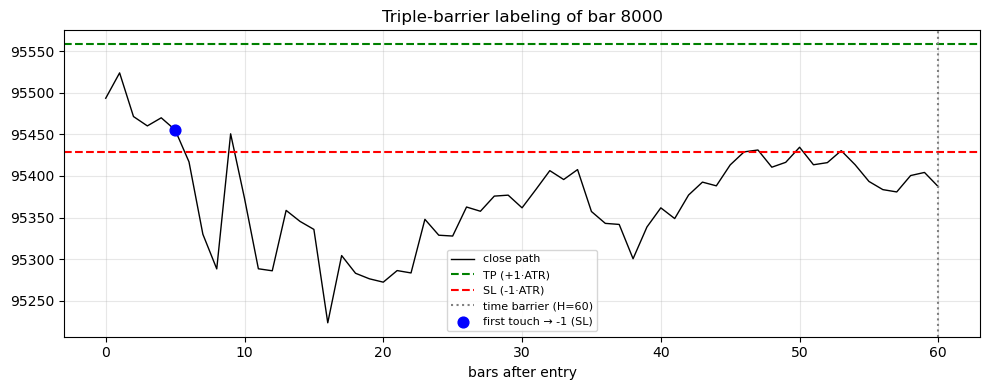

In [6]:
i = 8000                                      # a sample entry bar
H = 60
entry = c.iloc[i]; a = atr.iloc[i]
tp, sl = entry + a, entry - a
path = c.iloc[i:i+H+1].to_numpy()
hi = bars["high"].iloc[i:i+H+1].to_numpy(); lo = bars["low"].iloc[i:i+H+1].to_numpy()
touch = next((j for j in range(1, len(path)) if hi[j] >= tp or lo[j] <= sl), None)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(path, color="black", lw=1, label="close path")
ax.axhline(tp, color="green", ls="--", label="TP (+1·ATR)")
ax.axhline(sl, color="red", ls="--", label="SL (-1·ATR)")
ax.axvline(H, color="gray", ls=":", label="time barrier (H=60)")
if touch is not None:
    hit = "+1 (TP)" if hi[touch] >= tp else "-1 (SL)"
    ax.scatter([touch], [path[touch]], color="blue", zorder=5, s=60, label=f"first touch → {hit}")
ax.set_title(f"Triple-barrier labeling of bar {i}"); ax.set_xlabel("bars after entry"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 5 · Class balance — and an honest, important result

> 📘 **Concept — class balance.** For a classification label, what fraction is each class? A wildly
> imbalanced label (e.g. 99% "no") makes "always say no" look 99% accurate while being useless. A
> ~50/50 label is easy to *learn from* — but here it also delivers a sobering message.

Our symmetric 1×ATR barrier comes out around **49% / 51%** on this year (≈ 49.6% / 50.4% across the
full multi-year set) — a coin flip. That's not a bug; it's the headline finding that shapes the entire
strategy search:

In [7]:
rate = (obs[obs!=0]==1).mean()
print(f"TP-before-SL rate (symmetric 1xATR): {rate:.1%}")
print("\nWhy this matters: with symmetric barriers and ~50% base rate, no single feature will look")
print("predictive. Discovery (notebook 08) confirms exactly this — and it pushes the real strategies")
print("toward ASYMMETRIC targets + REGIME conditioning instead of a lone magic indicator.")

TP-before-SL rate (symmetric 1xATR): 49.0%

Why this matters: with symmetric barriers and ~50% base rate, no single feature will look
predictive. Discovery (notebook 08) confirms exactly this — and it pushes the real strategies
toward ASYMMETRIC targets + REGIME conditioning instead of a lone magic indicator.


## Step 6 · The finished dataset = features ⨝ labels on `ts`

`pipeline.labels.build_labels` packages `fwd_ret_{5,10,20,60}` + `hit_tp_before_sl`. Joined to the
feature frame on `ts`, that pair **(X = features, y = labels)** is the table every downstream phase
consumes. The shipped files are `data/features/…` and `data/labels/…`.

In [8]:
L = lab.build_labels(bars)
feats = pd.read_parquet(DATA / "features" / "features_btcusd_M3.parquet")
labs  = pd.read_parquet(DATA / "labels"   / "labels_btcusd_M3.parquet")
dataset = feats.merge(labs, on="ts", how="inner")
print(f"features: {feats.shape}   labels: {labs.shape}")
print(f"joined supervised dataset: {dataset.shape}  (this is what discovery & backtests read)")
dataset[["ts", "close", "adx", "dist_poc", "hour", "fwd_ret_10", "hit_tp_before_sl"]].dropna().head(4)

features: (424729, 43)   labels: (424729, 6)
joined supervised dataset: (424729, 48)  (this is what discovery & backtests read)


,ts,close,adx,dist_poc,hour,fwd_ret_10,hit_tp_before_sl
480,2024-01-02 00:00:00,"44,247.3",61.2556,0.0371522,0,0.0109724,1
481,2024-01-02 00:03:00,"44,401.9",63.2013,0.0405037,0,0.00656785,1
482,2024-01-02 00:06:00,"44,466.3",65.1318,0.0418926,0,0.00361173,1
483,2024-01-02 00:09:00,"44,563.7",66.9892,0.0439866,0,0.00355132,1


## 🎯 Your turn

1. **Asymmetric barriers.** Re-run Step 3 with `tp_mult=2.0, sl_mult=1.0` (risk 1 to make 2). How does
   the +1/−1/timeout mix shift? This is the *first* lever the real strategies pull.
2. **Horizon sensitivity.** Try `horizon=20` vs `120`. Shorter horizons → more timeouts. What does that
   imply about how long edges persist on M3?
3. **Does any feature move the rate?** Group `hit_tp_before_sl` by `hour` (join on `ts`). Do some hours
   have a TP-rate meaningfully above 49.6%? (Preview of discovery.)
4. **Label gold.** You built XAU bars earlier — run `build_labels` on them. You now have a full
   feature+label dataset for gold that doesn't exist in the repo yet.

➡️ **Next:** notebook **05** — with `(X, y)` in hand, the *exploratory data analysis* begins.